# Credit Card Financial Portfolio & Risk Analytics
### Author: **Yogesh Birla** | [GitHub: @yogs011](https://github.com/yogs011/citi-credit-card-portfolio-analytics)
**Core Stack:** `Power BI` | `DAX` | `Pandas` | `NumPy` | `EDA` | `Star Schema Modeling` | `ETL`

---

## 📌 Project Overview
This project delivers an end-to-end data analytics solution covering **10,000+ credit card accounts** and **$55M+ in transaction volume**.

### Pipeline Architecture:
1. **ETL Pipeline**: Extract raw transaction and demographic data, perform cleansing, handle missing values, and normalize features using Pandas and NumPy.
2. **Star Schema Data Modeling**: Architect `fact_credit_card`, `dim_customer`, and `dim_date` structures.
3. **Exploratory Data Analysis (EDA)**: Calculate executive KPIs (Total Revenue, Delinquency Rate, ARPU, Spend Channel Distribution).
4. **Power BI & DAX Measures**: Power the reporting layer with 15+ custom DAX measures (Time Intelligence, WoW Growth, Risk Metrics).

## 1. ETL Pipeline: Extraction & Ingestion
Ingesting base and supplementary Week-53 CSV datasets.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

# 1. Extract raw data files
cc = pd.read_csv('credit_card.csv')
cust = pd.read_csv('customer.csv')
cc_add = pd.read_csv('cc_add.csv')
cust_add = pd.read_csv('cust_add.csv')

# Combine datasets
cc_raw = pd.concat([cc, cc_add], ignore_index=True)
cust_raw = pd.concat([cust, cust_add], ignore_index=True)

print(f'Total Credit Card Records Extracted: {len(cc_raw):,}')
print(f'Total Customer Demographic Records Extracted: {len(cust_raw):,}')

Total Credit Card Records Extracted: 10,293
Total Customer Demographic Records Extracted: 10,293


## 2. ETL Pipeline: Transformation & Cleansing
Cleansing string whitespaces, formatting dates, parsing numeric fields, and engineering demographic tiers.

In [2]:
# Clean column headers
cc_raw.columns = cc_raw.columns.str.strip()
cust_raw.columns = cust_raw.columns.str.strip()

if 'Use Chip' in cc_raw.columns:
    cc_raw.rename(columns={'Use Chip': 'Use_Chip'}, inplace=True)
if 'Exp Type' in cc_raw.columns:
    cc_raw.rename(columns={'Exp Type': 'Exp_Type'}, inplace=True)

# Clean string columns
cc_raw['Card_Category'] = cc_raw['Card_Category'].str.strip()
cc_raw['Use_Chip'] = cc_raw['Use_Chip'].str.strip()
cc_raw['Exp_Type'] = cc_raw['Exp_Type'].str.strip()
cust_raw['Gender'] = cust_raw['Gender'].str.strip()
cust_raw['Education_Level'] = cust_raw['Education_Level'].str.strip()
cust_raw['Customer_Job'] = cust_raw['Customer_Job'].str.strip()

# Feature Transformations
cc_raw['Delinquent_Acc'] = pd.to_numeric(cc_raw['Delinquent_Acc'], errors='coerce').fillna(0).astype(int)
cc_raw['Week_Start_Date'] = pd.to_datetime(cc_raw['Week_Start_Date'], format='%d-%m-%Y', errors='coerce')
cc_raw['Total_Revenue'] = cc_raw['Annual_Fees'] + cc_raw['Total_Trans_Amt'] + cc_raw['Interest_Earned']

# Demographic Segmentation
cust_raw['Age_Group'] = pd.cut(
    cust_raw['Customer_Age'], 
    bins=[18, 30, 45, 60, 100], 
    labels=['18-30', '31-45', '46-60', '60+']
)
cust_raw['Income_Bracket'] = pd.cut(
    cust_raw['Income'],
    bins=[-1, 35000, 70000, 120000, 1000000],
    labels=['Low (<$35k)', 'Moderate ($35k-$70k)', 'High ($70k-$120k)', 'Executive (>$120k)']
)

print('Missing Values Check (Credit Card):', cc_raw.isnull().sum().sum())
print('Missing Values Check (Customer):', cust_raw.isnull().sum().sum())

Missing Values Check (Credit Card): 10293
Missing Values Check (Customer): 0


## 3. Star Schema Data Modeling
Constructing `dim_customer`, `dim_date`, and `fact_credit_card` tables.

In [3]:
# 1. Customer Dimension
dim_customer = cust_raw.drop_duplicates(subset=['Client_Num']).copy()

# 2. Date Dimension
dim_date = cc_raw[['Week_Start_Date', 'Week_Num', 'Qtr', 'current_year']].drop_duplicates().copy()
dim_date.rename(columns={'Week_Start_Date': 'Date_Key', 'current_year': 'Current_Year'}, inplace=True)
dim_date['Week_Num_Int'] = dim_date['Week_Num'].str.extract(r'(\d+)').astype(int)
dim_date['Month_Name'] = dim_date['Date_Key'].dt.strftime('%B')

# 3. Fact Table
fact_credit_card = cc_raw.copy()
fact_credit_card.rename(columns={'Week_Start_Date': 'Date_Key'}, inplace=True)

# Merged Master DataFrame for Exploratory Analysis
df = pd.merge(fact_credit_card, dim_customer, on='Client_Num', how='inner')
print(f'Star Schema Merged Records: {df.shape[0]:,} rows, {df.shape[1]} columns across {dim_customer["Client_Num"].nunique():,} unique clients.')
df.head()

Star Schema Merged Records: 10,293 rows, 36 columns across 10,293 unique clients.


,Client_Num,Card_Category,Annual_Fees,Activation_30_Days,Customer_Acq_Cost,Date_Key,Week_Num,Qtr,current_year,Credit_Limit,...,Zipcode,Car_Owner,House_Owner,Personal_loan,contact,Customer_Job,Income,Cust_Satisfaction_Score,Age_Group,Income_Bracket
0,708082083,Blue,200,0,87,2023-01-01,Week-1,Q1,2023,3544.0,...,91750,no,yes,no,unknown,Businessman,202326,3,18-30,Executive (>$120k)
1,708083283,Blue,445,1,108,2023-01-01,Week-1,Q1,2023,3421.0,...,91750,no,no,no,cellular,Selfemployeed,5225,2,60+,Low (<$35k)
2,708084558,Blue,140,0,106,2023-01-01,Week-1,Q1,2023,8258.0,...,91750,yes,no,no,unknown,Selfemployeed,14235,2,31-45,Low (<$35k)
3,708085458,Blue,250,1,150,2023-01-01,Week-1,Q1,2023,1438.3,...,91750,no,no,no,cellular,Blue-collar,45683,1,31-45,Moderate ($35k-$70k)
4,708086958,Blue,320,1,106,2023-01-01,Week-1,Q1,2023,3128.0,...,91750,yes,yes,no,cellular,Businessman,59279,1,46-60,Moderate ($35k-$70k)


## 4. Executive Portfolio KPIs & Financial Summary

In [4]:
total_accounts = df['Client_Num'].nunique()
total_trans_amt = df['Total_Trans_Amt'].sum()
total_trans_vol = df['Total_Trans_Vol'].sum()
total_interest = df['Interest_Earned'].sum()
total_annual_fees = df['Annual_Fees'].sum()
total_revenue = total_annual_fees + total_trans_amt + total_interest
delinquency_rate = df['Delinquent_Acc'].mean() * 100
avg_utilization = df['Avg_Utilization_Ratio'].mean() * 100
arpu = total_revenue / total_accounts

kpi_summary = pd.DataFrame({
    'KPI Metric': [
        'Total Active Accounts',
        'Total Transaction Amount ($)',
        'Total Transactions Volume (#)',
        'Interest Earned Revenue ($)',
        'Annual Fees Collected ($)',
        'Total Combined Portfolio Volume ($)',
        'Average Revenue Per User (ARPU)',
        'Portfolio Delinquency Rate (%)',
        'Average Credit Utilization (%)'
    ],
    'Value': [
        f'{total_accounts:,}',
        f'${total_trans_amt:,.2f}',
        f'{total_trans_vol:,.0f}',
        f'${total_interest:,.2f}',
        f'${total_annual_fees:,.2f}',
        f'${total_revenue:,.2f}',
        f'${arpu:,.2f}',
        f'{delinquency_rate:.2f}%',
        f'{avg_utilization:.2f}%'
    ]
})
display(kpi_summary)

,KPI Metric,Value
0,Total Active Accounts,"10,293"
1,Total Transaction Amount ($),"$45,533,021.00"
2,Total Transactions Volume (#),"655,651"
3,Interest Earned Revenue ($),"$7,982,479.81"
4,Annual Fees Collected ($),"$3,001,510.00"
5,Total Combined Portfolio Volume ($),"$56,517,010.81"
6,Average Revenue Per User (ARPU),"$5,490.82"
7,Portfolio Delinquency Rate (%),6.06%
8,Average Credit Utilization (%),27.45%


## 5. Exploratory Data Analysis (EDA) & Visualizations

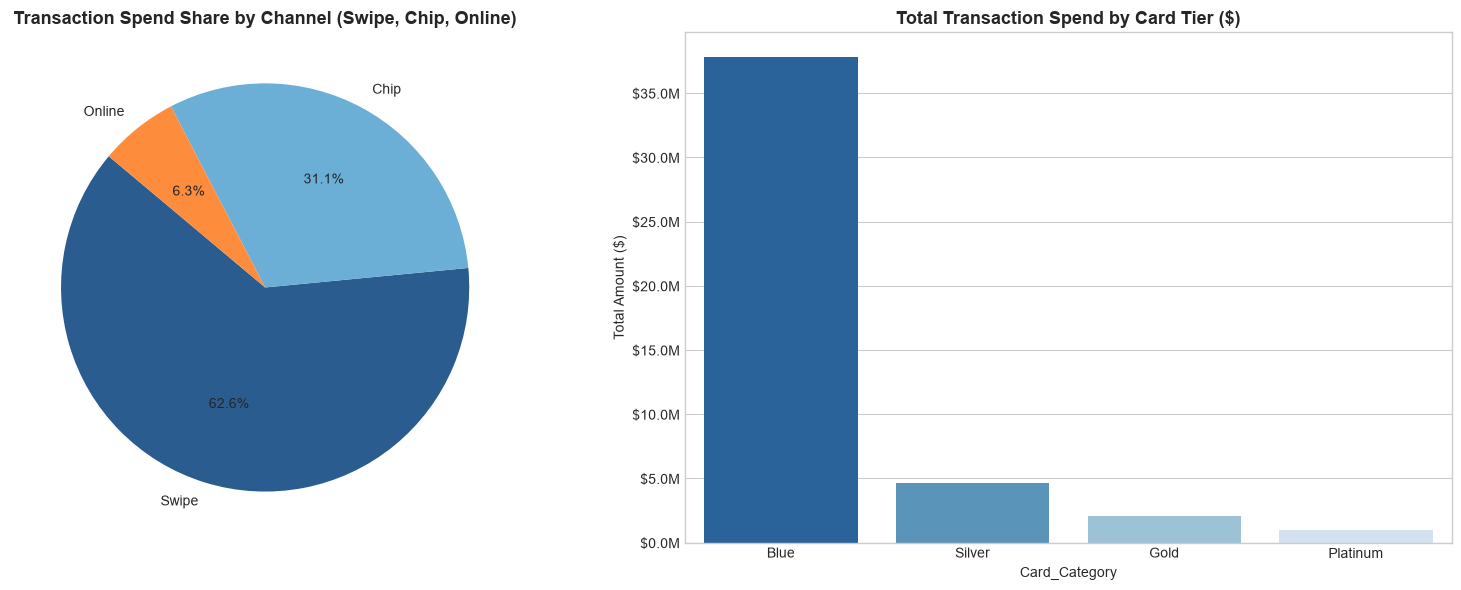

In [5]:
# Spend by Channel & Card Category Breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Spend Channel Distribution (Chip, Swipe, Online)
channel_spend = df.groupby('Use_Chip')['Total_Trans_Amt'].sum().sort_values(ascending=False)
axes[0].pie(channel_spend, labels=channel_spend.index, autopct='%1.1f%%', colors=['#2b5c8f', '#6baed6', '#fd8d3c'], startangle=140)
axes[0].set_title('Transaction Spend Share by Channel (Swipe, Chip, Online)', fontsize=13, fontweight='bold')

# Right: Total Spend by Card Category
tier_spend = df.groupby('Card_Category')['Total_Trans_Amt'].sum().sort_values(ascending=False)
sns.barplot(x=tier_spend.index, y=tier_spend.values, hue=tier_spend.index, palette='Blues_r', legend=False, ax=axes[1])
axes[1].set_title('Total Transaction Spend by Card Tier ($)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Amount ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x*1e-6:.1f}M'))

plt.tight_layout()
plt.show()

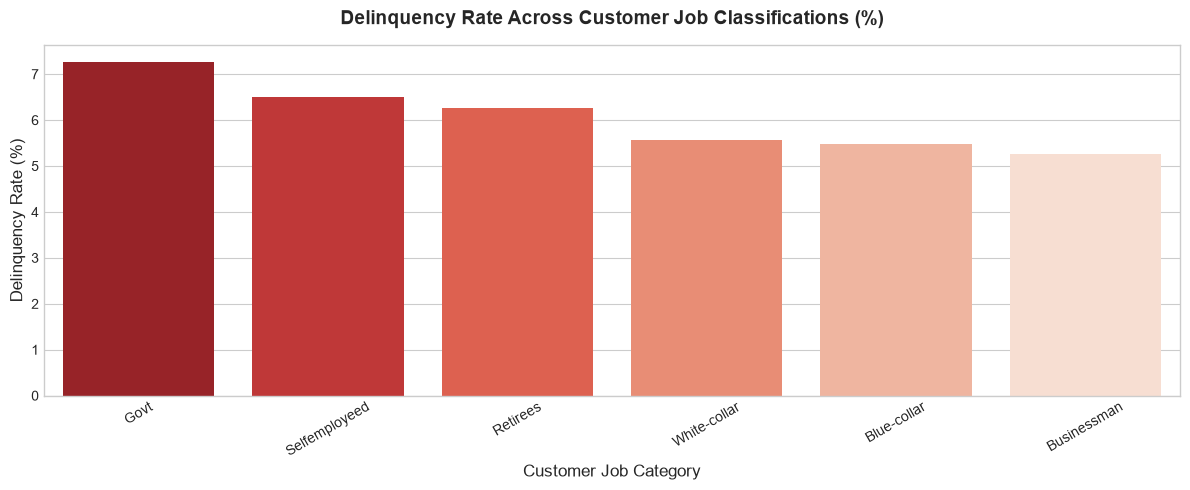

In [6]:
# Delinquency Risk Profile across Customer Income & Job Tiers
plt.figure(figsize=(12, 5))
job_risk = df.groupby('Customer_Job')['Delinquent_Acc'].mean().sort_values(ascending=False) * 100
sns.barplot(x=job_risk.index, y=job_risk.values, hue=job_risk.index, palette='Reds_r', legend=False)
plt.title('Delinquency Rate Across Customer Job Classifications (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Job Category', fontsize=12)
plt.ylabel('Delinquency Rate (%)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Power BI & DAX Measure Integration Summary

The analytical metrics engineered in this pipeline are mirrored in the Power BI reporting layer through **15+ custom DAX measures** (see [`dax_measures.dax`](./dax_measures.dax)):
- **`[Total_Revenue]`**: `SUM(fact_credit_card[Annual_Fees]) + SUM(fact_credit_card[Total_Trans_Amt]) + SUM(fact_credit_card[Interest_Earned])`
- **`[Current_Week_Revenue]`** & **`[Previous_Week_Revenue]`**: Dynamic Time-Intelligence filter over `dim_date`.
- **`[WoW_Revenue_Growth]`**: Week-over-Week percentage change in net portfolio yield.
- **`[Delinquency_Rate]`**: Percentage of accounts flagged with 30-day default.
- **`[ARPU]`**: Average revenue generated per cardholder account.

---